### Scatters

In [1]:
import polars as pl
import numpy as np
import pandas as pd
from plotnine import *

In [2]:
(relievers := pl.read_parquet('data/Statcast_relievers.parquet')).head(2)

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""


In [3]:
(outing_table := pl.read_parquet('data/outing_table.parquet')).head(2)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876


# Scatter Plots - Velocity/Spin Rate

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 220 rows containing missing values.


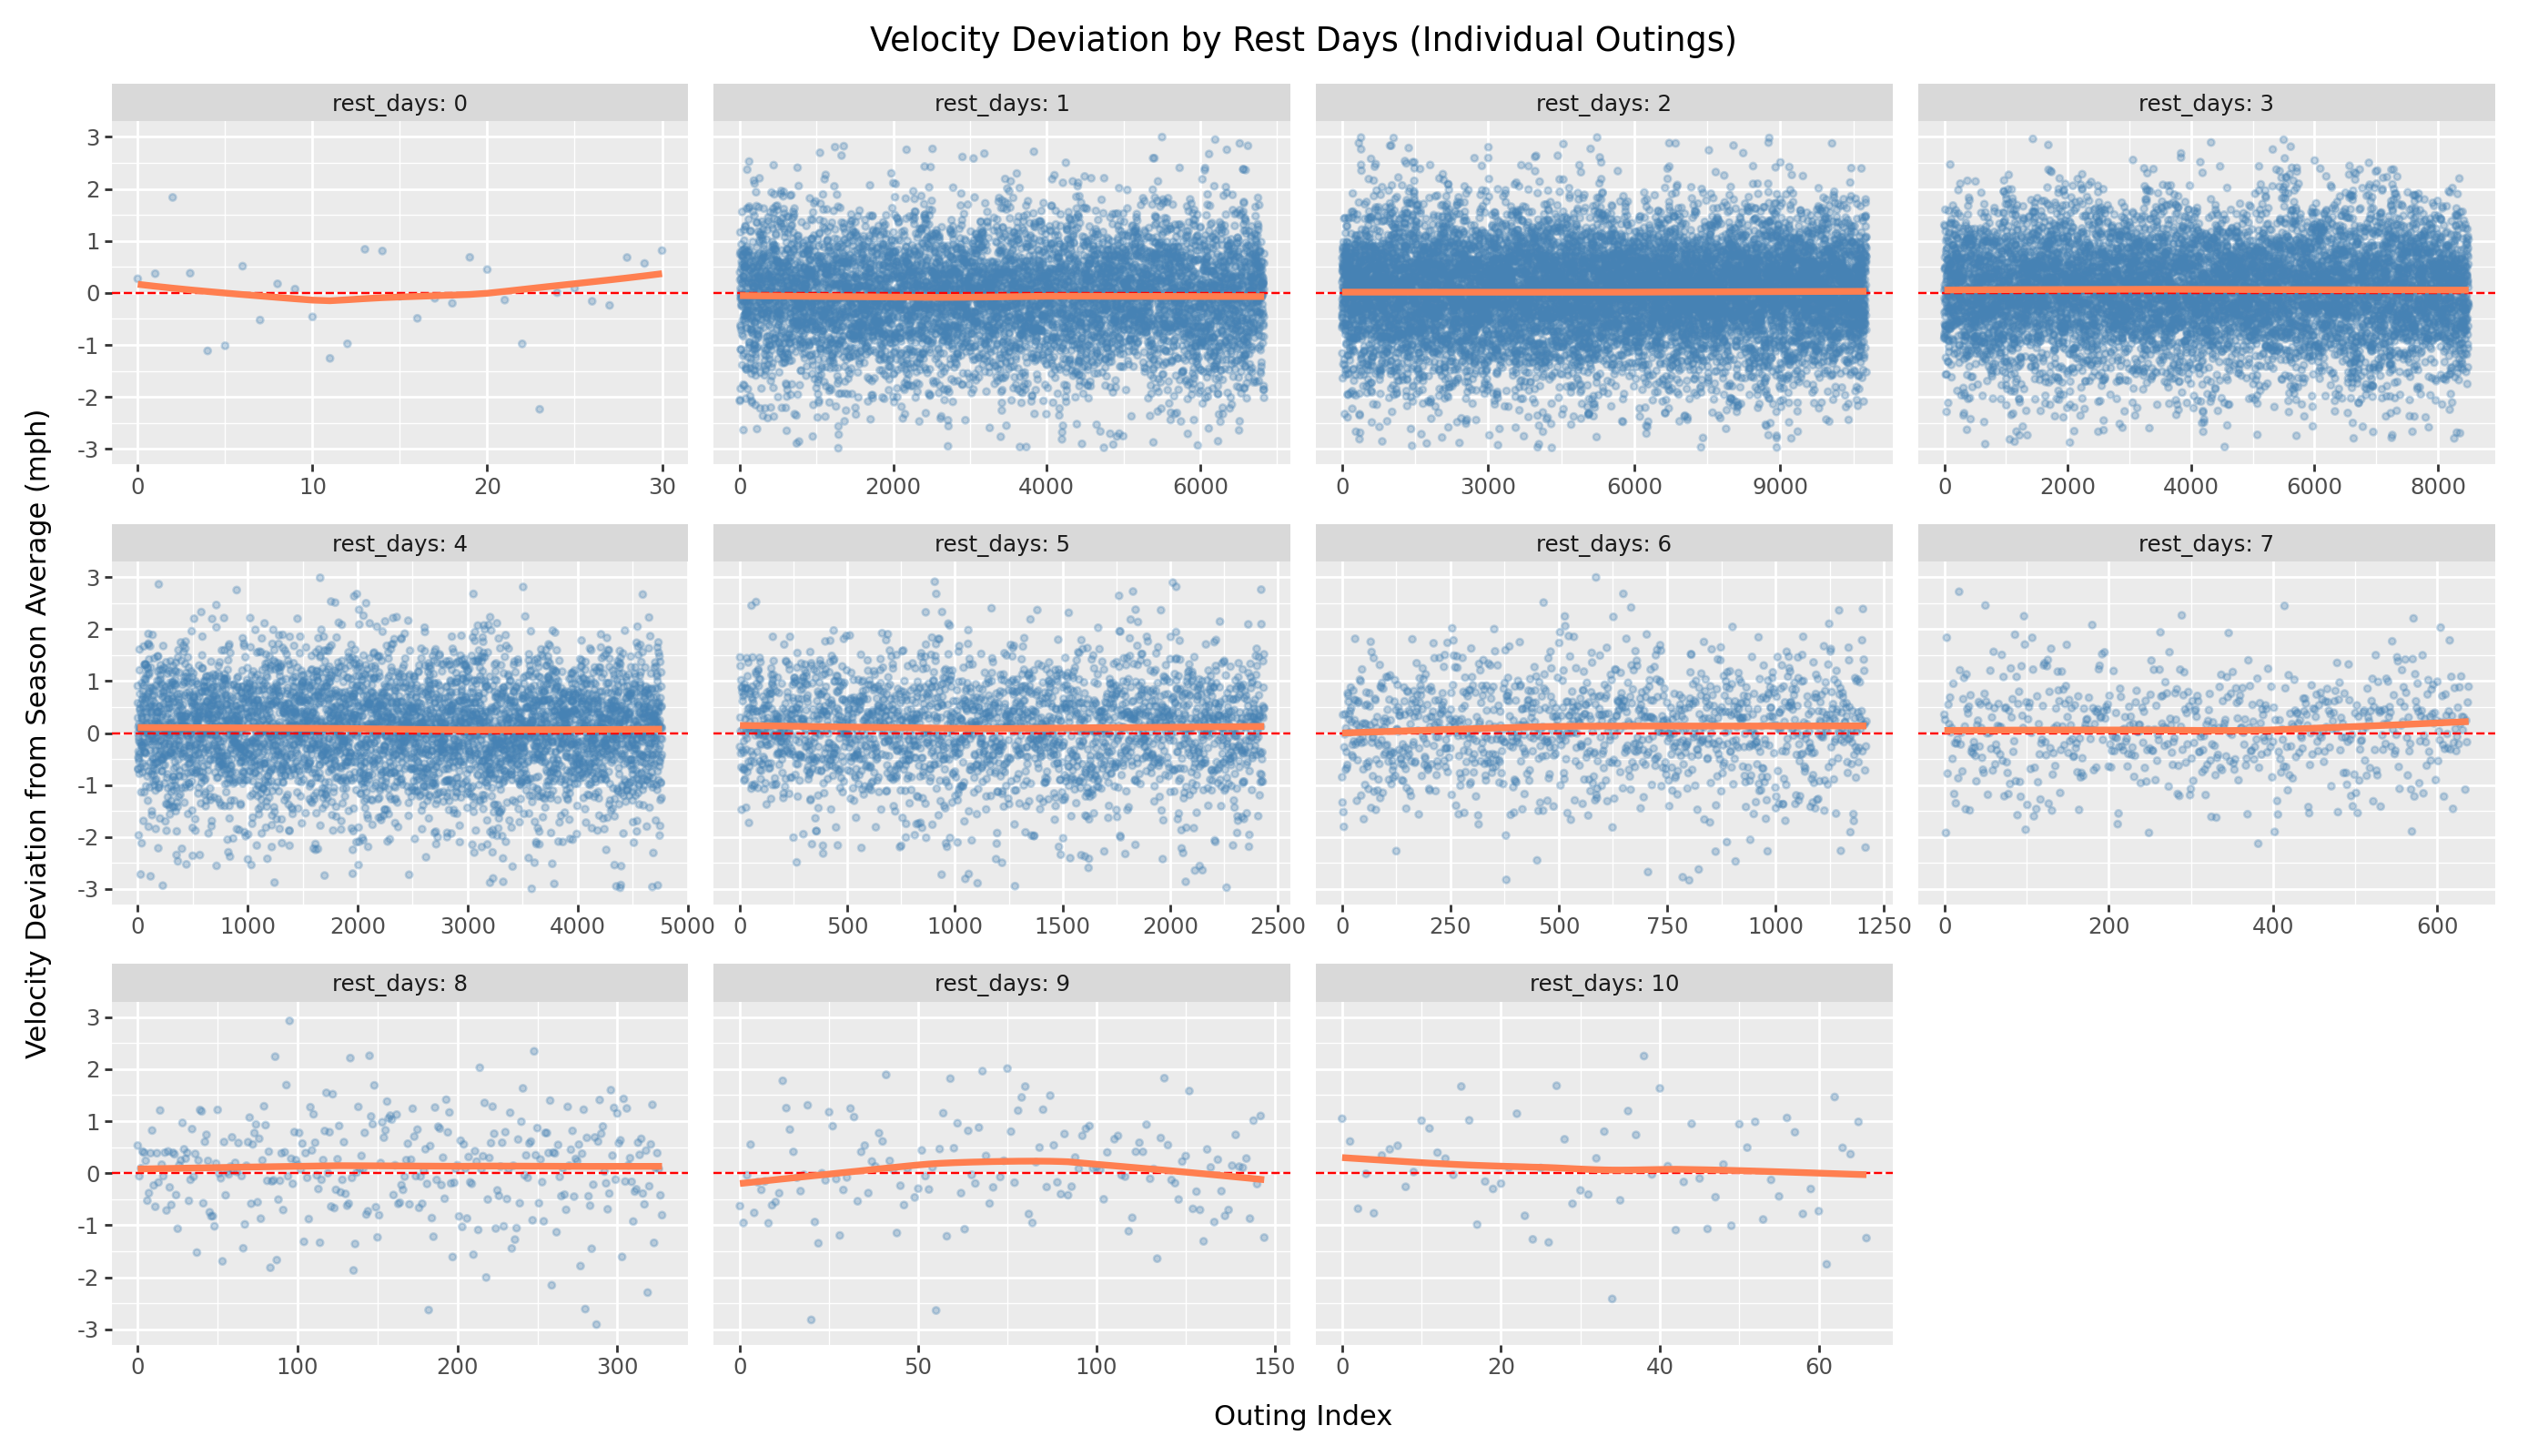

In [4]:
# Velocity deviation: Scatter plot faceted by rest day with LOWESS
from plotnine import *

scatter_data = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .select(['rest_days', 'velo_deviation', 'spin_deviation'])
    .to_pandas()
)

# Add a sequential index within each rest day group for LOWESS
scatter_data = scatter_data.sort_values('rest_days')
scatter_data['index_within_group'] = scatter_data.groupby('rest_days').cumcount()

# Velocity deviation with custom y-axis
(ggplot(scatter_data, aes(x='index_within_group', y='velo_deviation')) +
 geom_point(alpha=0.3, color='steelblue', size=1) +
 geom_hline(yintercept=0, linetype='dashed', color='red') +
 stat_smooth(method='lowess', color='coral', size=1.5, se=False) +
 facet_wrap('~rest_days', ncol=4, labeller='label_both', scales='free_x') +
 scale_y_continuous(limits=(-3, 3), breaks=[-3, -2, -1, 0, 1, 2, 3]) +  # Custom y-axis
 labs(title='Velocity Deviation by Rest Days (Individual Outings)',
      x='Outing Index',
      y='Velocity Deviation from Season Average (mph)') +
 theme(figure_size=(14, 8)))

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 22807 rows containing missing values.


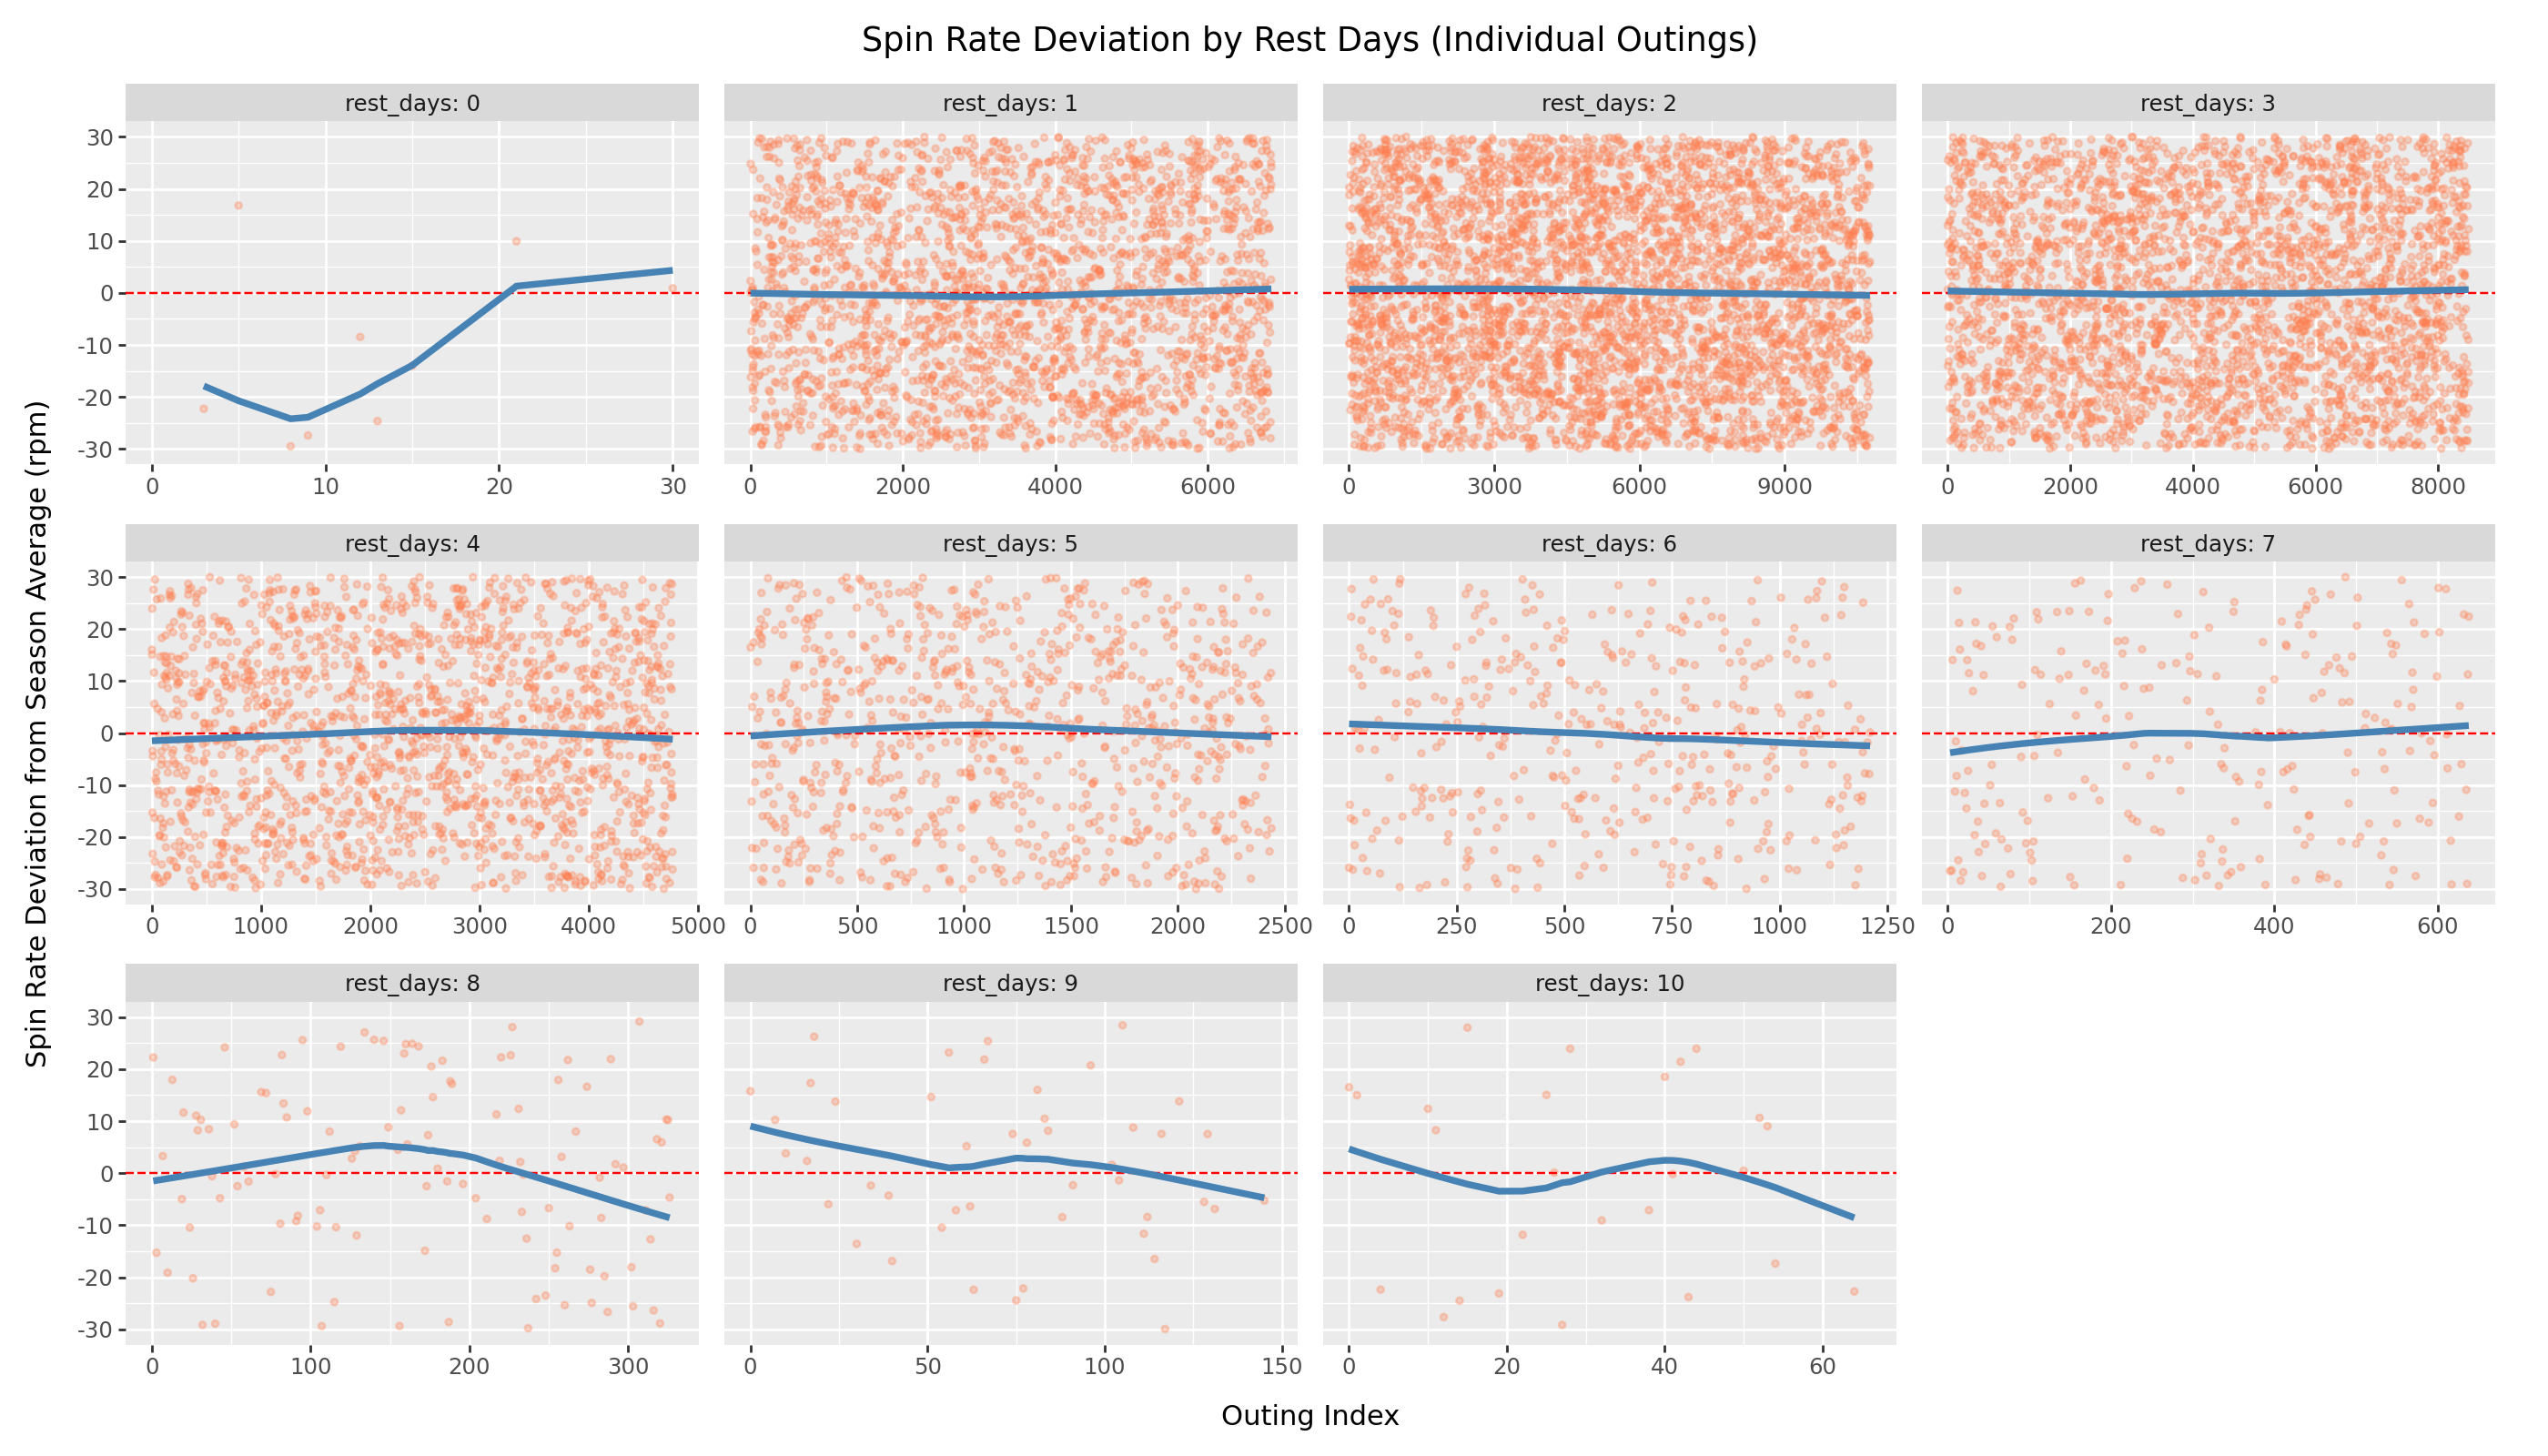

In [5]:
# Spin rate deviation: Scatter plot faceted by rest day with LOWESS
(ggplot(scatter_data, aes(x='index_within_group', y='spin_deviation')) +
 geom_point(alpha=0.3, color='coral', size=1) +
 geom_hline(yintercept=0, linetype='dashed', color='red') +
 stat_smooth(method='lowess', color='steelblue', size=1.5, se=False) +
 scale_y_continuous(limits=(-30, 30), breaks=[-30, -20, -10, 0, 10, 20, 30]) + 
 facet_wrap('~rest_days', ncol=4, labeller='label_both', scales='free_x') +
 labs(title='Spin Rate Deviation by Rest Days (Individual Outings)',
      x='Outing Index',
      y='Spin Rate Deviation from Season Average (rpm)') +
 theme(figure_size=(14, 8)))

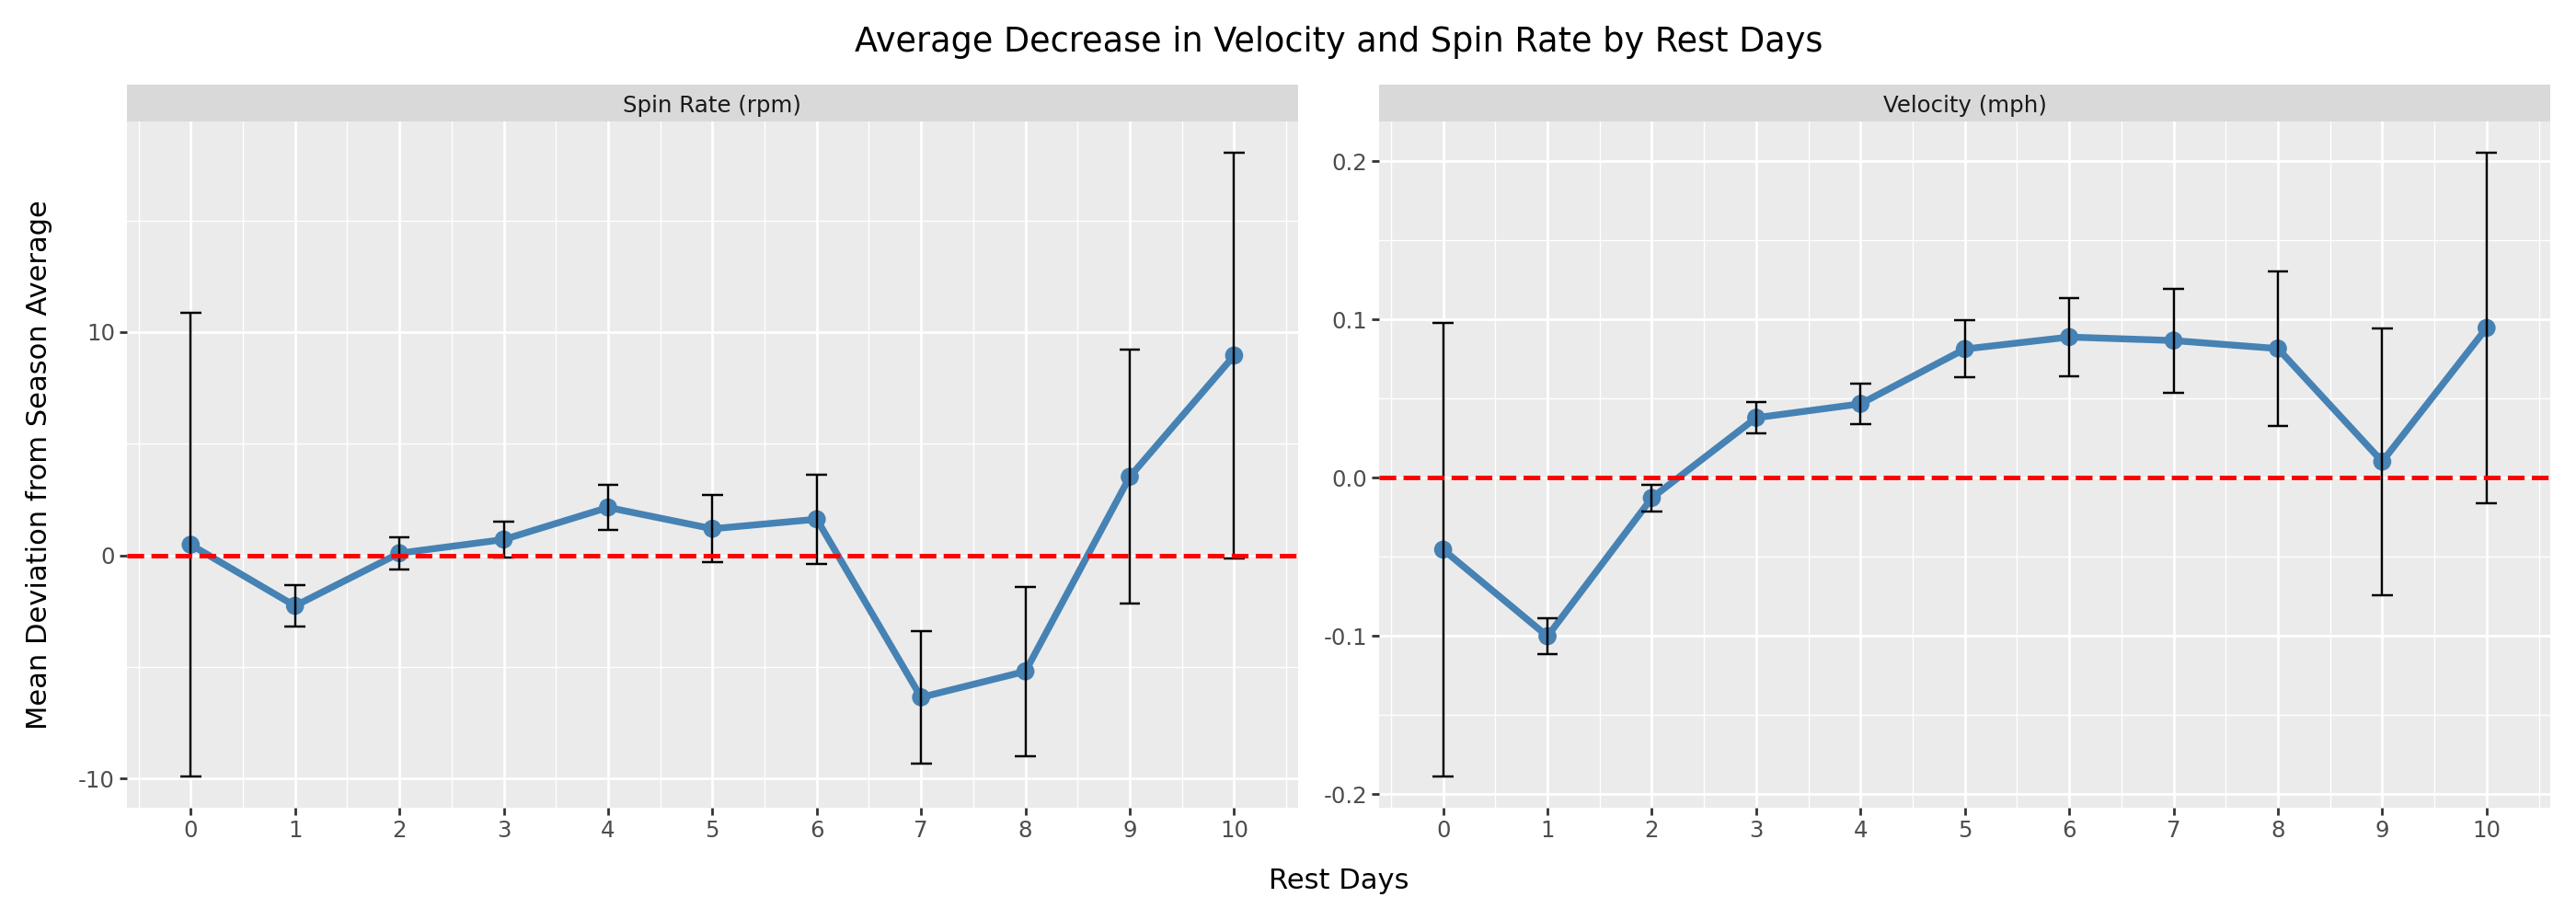

In [14]:
avg_by_rest = (outing_table
    .filter(pl.col('rest_days') <= 10)
    .group_by('rest_days')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.col('spin_deviation').mean().alias('mean_spin'),
        pl.col('velo_deviation').std().alias('std_velo'),
        pl.col('spin_deviation').std().alias('std_spin'),
        pl.len().alias('n')
    ])
    .with_columns([
        (pl.col('std_velo') / pl.col('n').sqrt()).alias('se_velo'),
        (pl.col('std_spin') / pl.col('n').sqrt()).alias('se_spin')
    ])
    .sort('rest_days')
    .to_pandas()
)

# Reshape for faceting
velo_df = avg_by_rest[['rest_days', 'mean_velo', 'se_velo']].copy()
velo_df['metric'] = 'Velocity (mph)'
velo_df.columns = ['rest_days', 'mean', 'se', 'metric']

spin_df = avg_by_rest[['rest_days', 'mean_spin', 'se_spin']].copy()
spin_df['metric'] = 'Spin Rate (rpm)'
spin_df.columns = ['rest_days', 'mean', 'se', 'metric']

combined = pd.concat([velo_df, spin_df])

(ggplot(combined, aes(x='rest_days', y='mean')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 geom_errorbar(aes(ymin='mean - se', ymax='mean + se'), width=0.2) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 facet_wrap('~metric', scales='free_y', ncol=2) +
 labs(title='Average Decrease in Velocity and Spin Rate by Rest Days',
      x='Rest Days',
      y='Mean Deviation from Season Average') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(14, 5)))

### Group Averages

In [13]:
# Calculate cumulative pitches thrown in last N days for each outing
(pitcher_cumulative_pitches := (outing_table
    .sort(['pitcher_id', 'date'])
    .with_columns([
        pl.col('pitch_count').rolling_sum_by('date', window_size='1d', closed='left').over('pitcher_id').alias('pitches_last_1d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='2d', closed='left').over('pitcher_id').alias('pitches_last_2d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='3d', closed='left').over('pitcher_id').alias('pitches_last_3d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='4d', closed='left').over('pitcher_id').alias('pitches_last_4d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='5d', closed='left').over('pitcher_id').alias('pitches_last_5d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='6d', closed='left').over('pitcher_id').alias('pitches_last_6d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='7d', closed='left').over('pitcher_id').alias('pitches_last_7d')
    ])
    .select(['pitcher_id', 'pitcher_name', 'date', 'pitch_count', 'rest_days', 
             'velo_deviation', 'spin_deviation',
             'pitches_last_1d', 'pitches_last_2d', 'pitches_last_3d', 
             'pitches_last_4d', 'pitches_last_5d', 'pitches_last_6d', 'pitches_last_7d'])
))

pitcher_cumulative_pitches.head(1)

pitcher_id,pitcher_name,date,pitch_count,rest_days,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,pitches_last_7d
i64,str,datetime[ns],u32,i64,f64,f64,u32,u32,u32,u32,u32,u32,u32
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,16,2,-1.524306,-59.365543,null,null,null,null,null,null,null


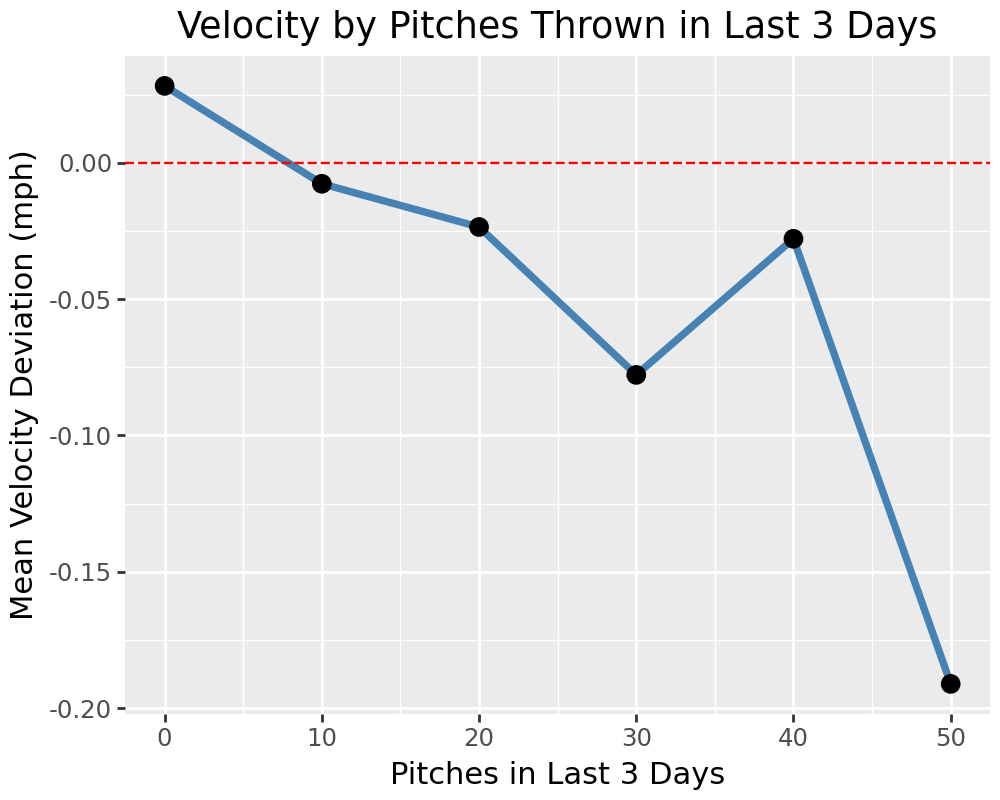

In [10]:
# Simple binned average
(simple_workload := (pitcher_cumulative_pitches
    .filter(pl.col('pitches_last_3d') <= 100)
    .with_columns([
        (pl.col('pitches_last_3d') // 10 * 10).alias('pitch_bin')
    ])
    .group_by('pitch_bin')
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.len().alias('n')
    ])
    .filter(pl.col('n') >= 50)
    .sort('pitch_bin')
    .to_pandas()
))

(ggplot(simple_workload, aes(x='pitch_bin', y='mean_velo')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(size=3) +
 geom_hline(yintercept=0, linetype='dashed', color='red') +
 labs(title='Velocity by Pitches Thrown in Last 3 Days',
      x='Pitches in Last 3 Days',
      y='Mean Velocity Deviation (mph)') +
 theme(figure_size=(5, 4)))

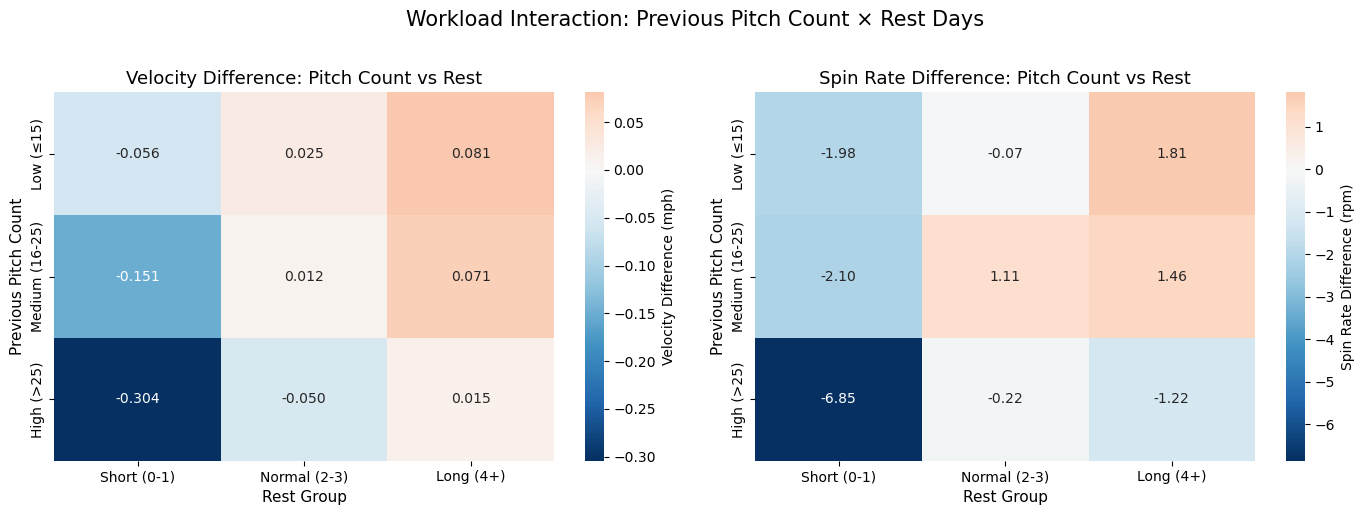

In [12]:
# Heatmaps: Velocity and Spin Rate difference by pitch count and rest days
import seaborn as sns
import matplotlib.pyplot as plt
(outing_with_groups := (outing_table
    .filter(pl.col('rest_days') <= 10)  # Consistent with Q1 analysis
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 15)
          .then(pl.lit('Low (≤15)'))
          .when(pl.col('prev_pitch_count') <= 25)
          .then(pl.lit('Medium (16-25)'))
          .otherwise(pl.lit('High (>25)'))
          .alias('prev_pitch_group'),

        pl.when(pl.col('rest_days') <= 1)
          .then(pl.lit('Short (0-1)'))
          .when(pl.col('rest_days') <= 3)
          .then(pl.lit('Normal (2-3)'))
          .otherwise(pl.lit('Long (4+)'))
          .alias('rest_group'),
    ])
))
(pitch_count_summary := outing_with_groups.group_by(['prev_pitch_group', 'rest_group']).agg([
    pl.col('velo_deviation').mean().alias('mean_velo_diff'),
    pl.col('spin_deviation').mean().alias('mean_spin_diff'),
    pl.len().alias('count'),
]).sort(['prev_pitch_group', 'rest_group']))
pivot_velo = (pitch_count_summary
    .select(['prev_pitch_group', 'rest_group', 'mean_velo_diff'])
    .to_pandas()
    .pivot(index='prev_pitch_group', columns='rest_group', values='mean_velo_diff')
    [['Short (0-1)', 'Normal (2-3)', 'Long (4+)']]
)
pivot_velo = pivot_velo.loc[['Low (≤15)', 'Medium (16-25)', 'High (>25)']]

pivot_spin = (pitch_count_summary
    .select(['prev_pitch_group', 'rest_group', 'mean_spin_diff'])
    .to_pandas()
    .pivot(index='prev_pitch_group', columns='rest_group', values='mean_spin_diff')
    [['Short (0-1)', 'Normal (2-3)', 'Long (4+)']]
)
pivot_spin = pivot_spin.loc[['Low (≤15)', 'Medium (16-25)', 'High (>25)']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Velocity heatmap
sns.heatmap(pivot_velo, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=ax1, cbar_kws={'label': 'Velocity Difference (mph)'})
ax1.set_title('Velocity Difference: Pitch Count vs Rest', fontsize=13)
ax1.set_xlabel('Rest Group', fontsize=11)
ax1.set_ylabel('Previous Pitch Count', fontsize=11)

# Spin rate heatmap
sns.heatmap(pivot_spin, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            ax=ax2, cbar_kws={'label': 'Spin Rate Difference (rpm)'})
ax2.set_title('Spin Rate Difference: Pitch Count vs Rest', fontsize=13)
ax2.set_xlabel('Rest Group', fontsize=11)
ax2.set_ylabel('Previous Pitch Count', fontsize=11)

fig.suptitle('Workload Interaction: Previous Pitch Count × Rest Days', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()